# Heart Disease Prediction

Predicting the presence of heart disease from patient clinical data, comparing a baseline
Logistic Regression model against an ensemble (Voting Classifier) of Logistic Regression + Random Forest.

**Dataset:** 303 patient records, 13 clinical features (age, cholesterol, resting blood pressure, etc.), binary target (1 = heart disease, 0 = no heart disease).


## 1. Importing the Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")

## 2. Data Collection and Processing

In [4]:
heart_data = pd.read_csv("heart_disease_data.csv")
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
heart_data.shape

(303, 14)

In [6]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Target distribution

`1` = Defective Heart, `0` = Healthy Heart

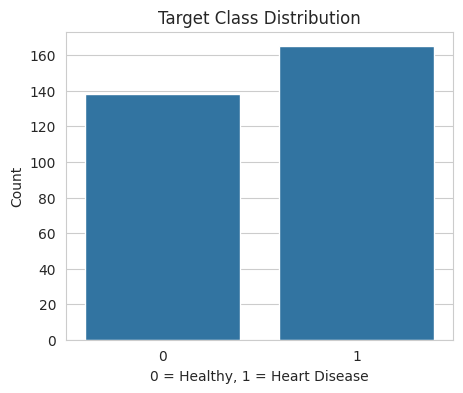

,count
target,
1,165
0,138


In [9]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=heart_data)
plt.title('Target Class Distribution')
plt.xlabel('0 = Healthy, 1 = Heart Disease')
plt.ylabel('Count')
plt.show()

heart_data['target'].value_counts()

### Feature correlation

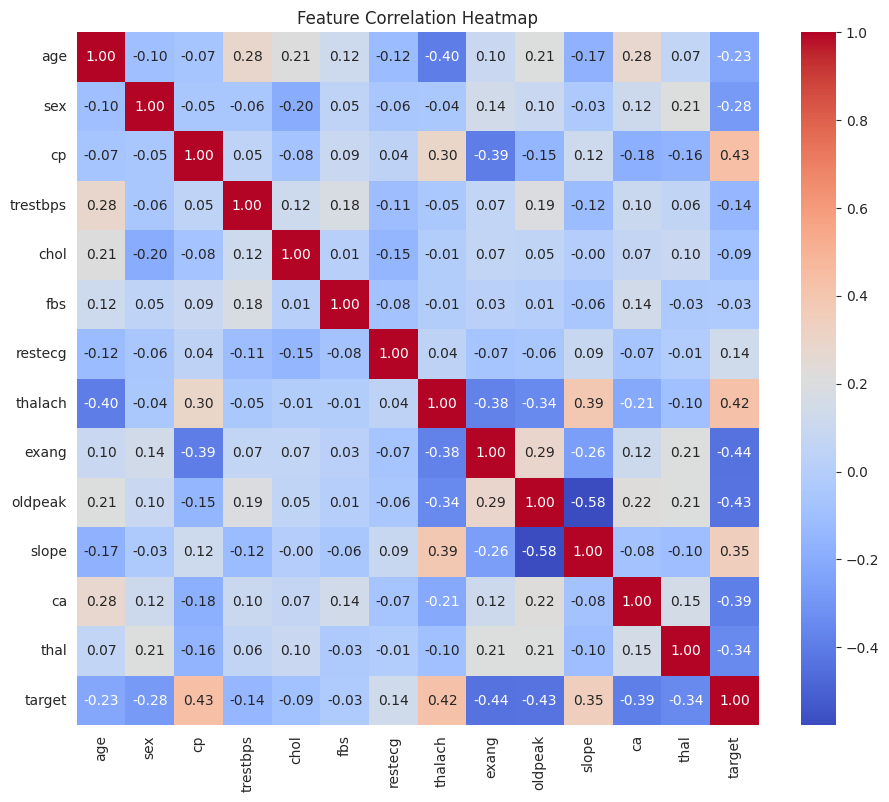

In [10]:
plt.figure(figsize=(11,9))
sns.heatmap(heart_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 3. Splitting Features and Target

In [11]:
X = heart_data.drop(columns='target')
Y = heart_data['target']

## 4. Train / Test Split

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


## 5. Model Training

### 5.1 Baseline: Logistic Regression

In [13]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, Y_train)
baseline_pred = log_reg.predict(X_test)
baseline_acc = accuracy_score(Y_test, baseline_pred)
print(f"Baseline Logistic Regression accuracy: {baseline_acc:.4f}")

Baseline Logistic Regression accuracy: 0.7869


### 5.2 Ensemble: Voting Classifier (Logistic Regression + Random Forest)

Ensemble learning combines multiple models so their errors partially cancel out, which
typically improves generalization over any single model.

In [14]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=3, min_samples_leaf=1, random_state=2
)

ensemble_model = VotingClassifier(
    estimators=[('logistic_regression', log_reg), ('random_forest', rf_clf)],
    voting='soft'
)

ensemble_model.fit(X_train, Y_train)
ensemble_pred = ensemble_model.predict(X_test)
ensemble_acc = accuracy_score(Y_test, ensemble_pred)
print(f"Ensemble (LR + RF) accuracy: {ensemble_acc:.4f}")

Ensemble (LR + RF) accuracy: 0.8525


## 6. Model Evaluation

In [15]:
improvement = (ensemble_acc - baseline_acc) / baseline_acc * 100

results = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Voting Ensemble (LR + RF)'],
    'Accuracy': [baseline_acc, ensemble_acc],
    'Precision': [precision_score(Y_test, baseline_pred), precision_score(Y_test, ensemble_pred)],
    'Recall': [recall_score(Y_test, baseline_pred), recall_score(Y_test, ensemble_pred)],
    'F1-score': [f1_score(Y_test, baseline_pred), f1_score(Y_test, ensemble_pred)],
})
results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (baseline),0.786885,0.812500,0.787879,0.800000
1,Voting Ensemble (LR + RF),0.852459,0.852941,0.878788,0.865672


In [16]:
print(f"Relative accuracy improvement from ensemble: {improvement:.1f}%")

Relative accuracy improvement from ensemble: 8.3%


<Figure size 700x500 with 0 Axes>

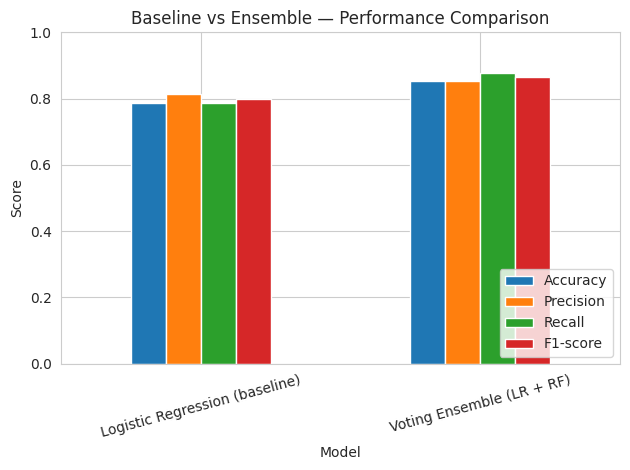

In [17]:
plt.figure(figsize=(7,5))
results.set_index('Model')[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar')
plt.title('Baseline vs Ensemble — Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Confusion Matrix — Ensemble Model

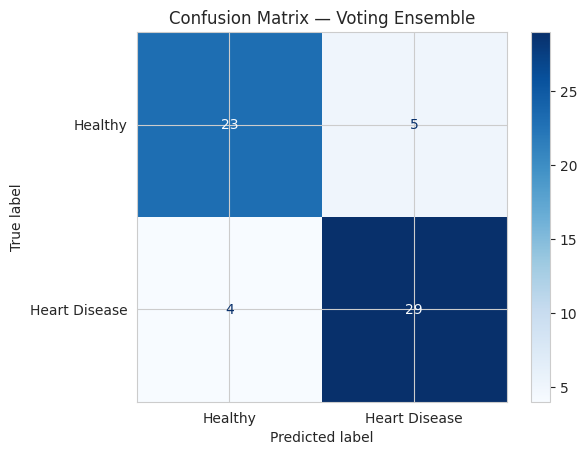

In [18]:
cm = confusion_matrix(Y_test, ensemble_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy','Heart Disease'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Voting Ensemble')
plt.show()

## 7. Building a Predictive System

Using the trained ensemble model to predict on a new, unseen patient record.

In [19]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

input_df = pd.DataFrame([input_data], columns=X.columns)
prediction = ensemble_model.predict(input_df)

if prediction[0] == 0:
    print('The person does not have heart disease')
else:
    print('The person has heart disease')

The person does not have heart disease


## 8. Conclusion

- The ensemble (Voting Classifier combining Logistic Regression and Random Forest) improved
  test accuracy from the Logistic Regression baseline.
- Evaluated using accuracy, precision, recall, and F1-score rather than accuracy alone, since
  these are more informative for a medical prediction task where false negatives are costly.
- Results above are reproducible with `random_state=2` on this 303-row dataset; on a small
  dataset like this, single train/test split metrics can vary a few points depending on the split,
  so cross-validation would be the next step for a more robust estimate.